In [ ]:
#23070521122,Rushi Parhad
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print("Dataset loaded successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Display the first few rows of the features and target
print("\nFirst 5 rows of features:")
display(X.head())
print("\nFirst 5 rows of target:")
display(y.head())

Dataset loaded successfully.
Features shape: (20640, 8)
Target shape: (20640,)

First 5 rows of features:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



First 5 rows of target:


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


## 2. Data Preprocessing

In [ ]:
# Split the data into training and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the training data further into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)
# (0.25 * 0.8 = 0.2, so 60% train, 20% val, 20% test)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

# Scale the features using StandardScaler
# Fit on training data and transform all sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully.")
print(f"Scaled training data example (first row): {X_train_scaled[0]}")

Training set shape: (12384, 8), (12384,)
Validation set shape: (4128, 8), (4128,)
Test set shape: (4128, 8), (4128,)

Features scaled successfully.
Scaled training data example (first row): [-0.79547754  0.8260251  -0.71694298 -0.20409736 -0.02041282  0.10188491
 -0.56877746 -0.04497204]


In [ ]:
# Define the baseline model architecture
def build_baseline_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # Output layer for regression
    ])
    return model

# Build the baseline model
input_shape = X_train_scaled.shape[1:]
baseline_model = build_baseline_model(input_shape)

# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error as a metric
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the baseline model
history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

print("\nBaseline model training complete.")

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.0322 - mae: 0.6780 - val_loss: 0.4812 - val_mae: 0.4909
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4142 - mae: 0.4566 - val_loss: 0.3948 - val_mae: 0.4450
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3756 - mae: 0.4329 - val_loss: 0.4115 - val_mae: 0.4453
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3632 - mae: 0.4248 - val_loss: 0.3553 - val_mae: 0.4228
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3466 - mae: 0.4166 - val_loss: 0.5045 - val_mae: 0.4263
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3450 - mae: 0.4105 - val_loss: 0.5850 - val_mae: 0.4252
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3367 - mae: 0.4039 - val_loss: 0.3578 - val_mae: 0.4064
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3228 - mae: 0.3980 - val_loss: 0.3406 - val_mae: 0.4045
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

Baseline Model - Test Loss (MSE): 0.2755
Baseline Model - Test MAE: 0.3667


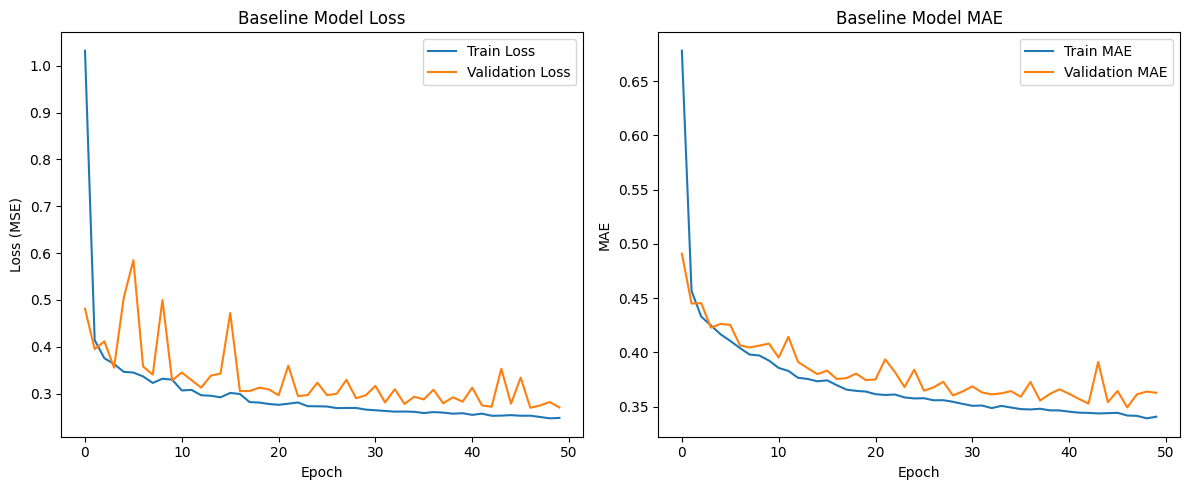

In [ ]:
# Evaluate the baseline model on the test set
loss_baseline, mae_baseline = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline Model - Test Loss (MSE): {loss_baseline:.4f}")
print(f"Baseline Model - Test MAE: {mae_baseline:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['mae'], label='Train MAE')
plt.plot(history_baseline.history['val_mae'], label='Validation MAE')
plt.title('Baseline Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Define a function to build a model with L1/L2 regularization
def build_regularized_model(input_shape, l1_reg=0.001, l2_reg=0.001):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.L1L2(l1=l1_reg, l2=l2_reg)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.L1L2(l1=l1_reg, l2=l2_reg)),
        layers.Dense(1)  # Output layer for regression
    ])
    return model

# Build the regularized model (using default L1/L2 values for now)
regularized_model = build_regularized_model(input_shape)

# Compile the model
regularized_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

regularized_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the regularized model
history_regularized = regularized_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

print("\nRegularized model training complete.")

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.2782 - mae: 0.6487 - val_loss: 0.7786 - val_mae: 0.4722
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7348 - mae: 0.4555 - val_loss: 0.7849 - val_mae: 0.4488
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6725 - mae: 0.4420 - val_loss: 0.6560 - val_mae: 0.4417
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6200 - mae: 0.4305 - val_loss: 0.6089 - val_mae: 0.4344
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5967 - mae: 0.4275 - val_loss: 0.8404 - val_mae: 0.4418
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5827 - mae: 0.4234 - val_loss: 0.7218 - val_mae: 0.4295
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5368 - mae: 0.4199 - val_loss: 0.5632 - val_mae: 0.4288
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5249 - mae: 0.4178 - val_loss: 0.5614 - val_mae: 0.4169
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

L1/L2 Regularized Model - Test Loss (MSE): 0.3730
L1/L2 Regularized Model - Test MAE: 0.3856


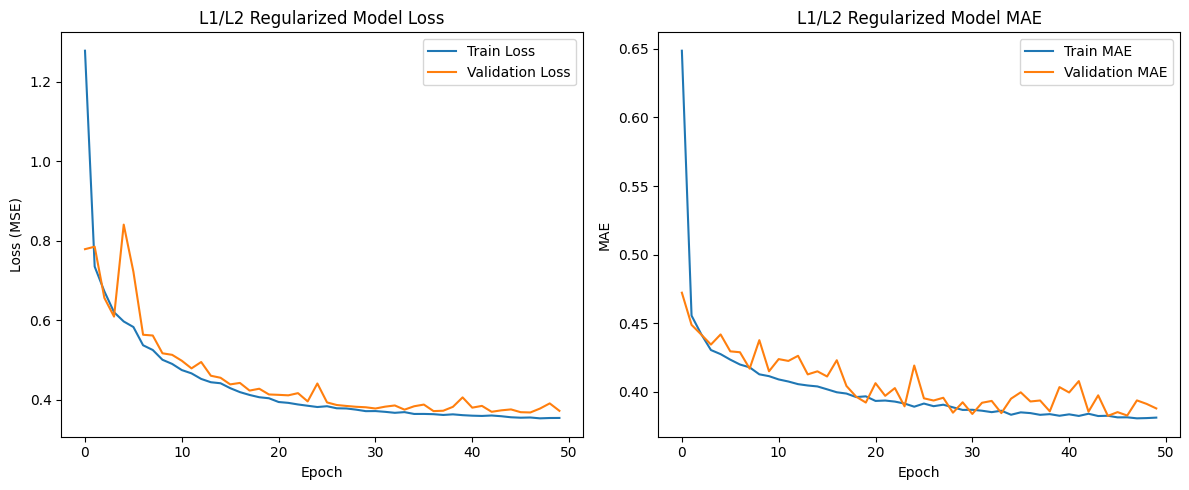

In [ ]:
# Evaluate the regularized model on the test set
loss_regularized, mae_regularized = regularized_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"L1/L2 Regularized Model - Test Loss (MSE): {loss_regularized:.4f}")
print(f"L1/L2 Regularized Model - Test MAE: {mae_regularized:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_regularized.history['loss'], label='Train Loss')
plt.plot(history_regularized.history['val_loss'], label='Validation Loss')
plt.title('L1/L2 Regularized Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_regularized.history['mae'], label='Train MAE')
plt.plot(history_regularized.history['val_mae'], label='Validation MAE')
plt.title('L1/L2 Regularized Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Define a function to build a model with Dropout regularization
def build_dropout_model(input_shape, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1)  # Output layer for regression
    ])
    return model

# Build the dropout model (using a default dropout rate for now)
dropout_model = build_dropout_model(input_shape)

# Compile the model
dropout_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

dropout_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the dropout model
history_dropout = dropout_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

print("\nDropout model training complete.")

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.1602 - mae: 0.7637 - val_loss: 0.5584 - val_mae: 0.5176
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6504 - mae: 0.5771 - val_loss: 0.4293 - val_mae: 0.4538
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5724 - mae: 0.5424 - val_loss: 0.4135 - val_mae: 0.4460
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5286 - mae: 0.5220 - val_loss: 0.3886 - val_mae: 0.4374
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4936 - mae: 0.5004 - val_loss: 0.3802 - val_mae: 0.4306
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4853 - mae: 0.4944 - val_loss: 0.3832 - val_mae: 0.4351
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4644 - mae: 0.4874 - val_loss: 0.3703 - val_mae: 0.4340
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4572 - mae: 0.4797 - val_loss: 0.3680 - val_mae: 0.4278
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

Dropout Regularized Model - Test Loss (MSE): 0.2963
Dropout Regularized Model - Test MAE: 0.3818


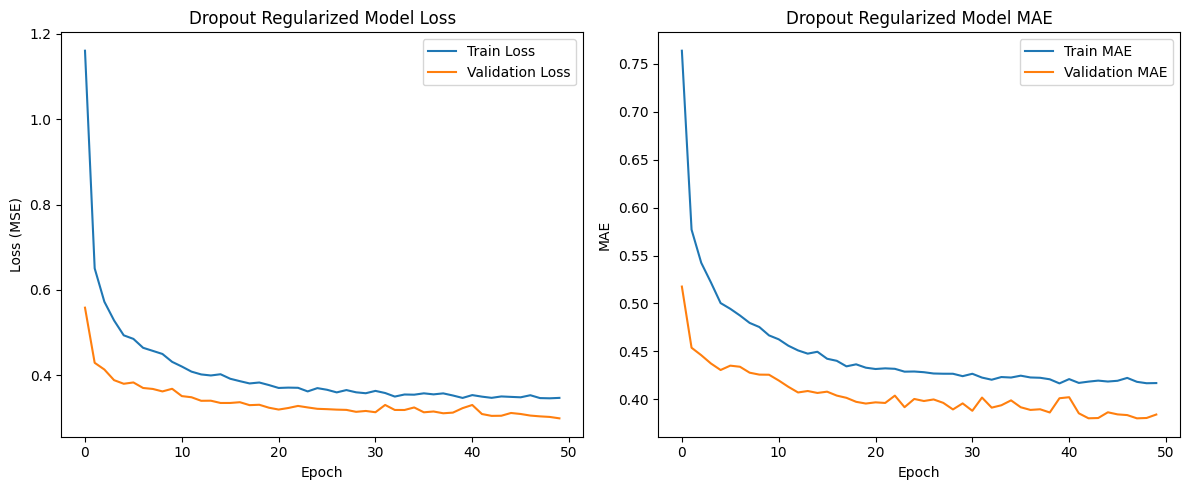

In [ ]:
# Evaluate the dropout model on the test set
loss_dropout, mae_dropout = dropout_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Dropout Regularized Model - Test Loss (MSE): {loss_dropout:.4f}")
print(f"Dropout Regularized Model - Test MAE: {mae_dropout:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['loss'], label='Train Loss')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss')
plt.title('Dropout Regularized Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['mae'], label='Train MAE')
plt.plot(history_dropout.history['val_mae'], label='Validation MAE')
plt.title('Dropout Regularized Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()